<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



# Etape 1 - Importation des librairies et chargement des fichiers

## 1. 1 - Importation des librairies

In [5]:
#Importation de la librairie Pandas
import pandas as pd

#Importation de la librairie Numpy
import numpy as np

#Importation de la librairie plotly express
import plotly.express as px

#Importation de la libairie matplotlib
import matplotlib.pyplot as plt

#Importation de la librairie seaborn
import seaborn as sns

In [6]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

## 1. 2 - Chargements des fichiers

In [7]:
#Liaison à faire
#from google.colab import drive
from google.colab import drive
drive.mount('/content/gdrive')

import os
print (os.getcwd())

os.chdir(r"/content/gdrive/My Drive/Colab Notebooks/Formation/P6")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/My Drive/Colab Notebooks/Formation/P6


In [8]:
#Importation du fichier web.xlsx
df_web = pd.read_csv("web.csv", sep=';', decimal=',')

#Importation du fichier erp.xlsx
df_erp = pd.read_csv("erp.csv", sep=';', decimal=',')

#Importation du fichier liaison.xlsx
df_liaison = pd.read_csv("liaison.csv", sep=';', decimal = ',')

# Etape 2 - Analyse exploratoire des fichiers

## 2. 1 - Analyse exploratoire du fichier erp.xlsx

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [10]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [11]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [12]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
#Il est possible de vérifier s'il y a des doublons en examinant les valeurs uniques
valeurs_uniques_erp = df_erp['product_id'].nunique()
print(valeurs_uniques_erp)

825


In [13]:
#Il y a exactement les mêmes nombres de valeurs uniques et d'entrées dans cette table donc il n'y a pas de doublons.

In [14]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
valeursDistinctesStockStatus = df_erp['stock_status'].nunique()
print(valeursDistinctesStockStatus)

2


In [15]:
valeursDistinctesStockStatus = df_erp['stock_status'].unique()
print(valeursDistinctesStockStatus)

['instock' 'outofstock']


In [16]:
# Existe-il des valeurs négatives dans la colonne "stock_quantity" ?
df_erp[df_erp["stock_quantity"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


In [17]:
#Les valeurs négatives seront considérées comme ayant un "stock_quantity" à 0
df_erp['stock_quantity'] = np.where(df_erp['stock_quantity'] < 0, 0, df_erp['stock_quantity'])
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [18]:
#Vérification des résultats
df_erp[df_erp["stock_quantity"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [19]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp = df_erp.assign(stock_status_2 = np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock'))
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [20]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [21]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
df_erp["stock_status"].unique() == df_erp["stock_status_2"].unique()

array([ True,  True])

In [22]:
df_erp["stock_status"].sum() == df_erp["stock_status_2"].sum()

False

In [23]:
df_erp["stock_status_2"].value_counts() == df_erp["stock_status"].value_counts()

,count
stock_status_2,
instock,True
outofstock,True


In [24]:
df_erp[df_erp["stock_status"]!=df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [25]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [26]:
#Corriger la ou les données incohérentes
df_erp['stock_status'] = np.where(df_erp['stock_status'] != df_erp['stock_status_2'], df_erp['stock_status_2'], df_erp['stock_status'])

In [27]:
#Verification en utilisant le même code que plus haut pour afficher les problemes
df_erp[df_erp["stock_status"]!=df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


### 2. 1. 1 - Analyse exploratoire de chaque variable du fichier erp.xlsx

#### 2. 1. 1. 1 - Analyse de la variable PRIX

In [28]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
df_erp["price"] = pd.to_numeric(df_erp["price"], errors='coerce')
prix_invalides = df_erp[df_erp["price"] <= 0]
prix_invalides

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [174]:
#Afficher le ou les prix non renseignés dans la colonne "price"
prix_invalides

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [30]:
#Afficher le prix minimum de la colonne "price"
prix_min = df_erp["price"].min()
print("Le prix minimum est de {} euros".format(prix_min)) #Saisir l'instruction manquante dans la fonction format

Le prix minimum est de -20.0 euros


In [31]:
#Afficher le prix maximum de la colonne "price"
prix_max = df_erp["price"].max()
print("Le prix maximum est de {} euros".format(prix_max)) #Saisir l'instruction manquante dans la fonction format

Le prix maximum est de 225.0 euros


In [32]:
#Afficher les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
prix_negatifs = df_erp[df_erp["price"] < 0]
prix_negatifs

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [33]:
#Remplacer les prix négatifs par 0
df_erp['price'] = np.where(df_erp['price'] < 0, 0, df_erp['price'])

In [34]:
#Vérifier si les modifications des prix négatifs ont bien été faites
prix_negatifs = df_erp[df_erp["price"] < 0]
prix_negatifs

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


#### 2. 1. 1. 2 - Analyse de la variable STOCK

In [35]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Les stocks négatifs ont été remplacés par 0 précédemment mais vérifions à nouveau
df_erp["stock_quantity"] = pd.to_numeric(df_erp["stock_quantity"], errors='coerce')
stocks_invalides = df_erp[df_erp["stock_quantity"] < 0]
print(stocks_invalides)


Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_2]
Index: []


In [36]:
#Afficher la quantité minimum de la colonne "stock_quantity"
df_erp["stock_quantity"].min()

0

In [37]:
#Afficher la quantité maximum de la colonne "stock_quantity"
df_erp["stock_quantity"].max()

145

In [38]:
#Afficher les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp[df_erp["stock_quantity"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


In [39]:
#Ici les stocks à 0 doivent être gardés car dans ce cas 0 est une valeur valide de stock.

#### 2. 1. 1. 3 - Analyse de la variable ONSALE_WEB

In [40]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
df_erp["onsale_web"].unique()

array([1, 0])

In [41]:
df_erp['onsale_web'].nunique()

2

In [42]:
#La colonne onsale_web contient les valeurs 0 ou 1. 0 signifie que le produit n'est pas vendu en ligne et 1 signifie que le produit est aussi vendu en ligne.

In [43]:
#Quelles sont les colonnes à conserver selon vous?


In [44]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=['stock_status_2'])

#### 2. 1. 1. 4 - Analyse de la variable prix d'achat

In [45]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp["purchase_price"] = pd.to_numeric(df_erp["purchase_price"], errors='coerce')
prix_achat_invalides = df_erp[df_erp["purchase_price"] <= 0]
print(prix_achat_invalides)


Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price]
Index: []


In [46]:
#Afficher le prix minimum de la colonne "purchase_price"
prix_achat_min = df_erp["purchase_price"].min()
print("Le prix minimum est de {} euros".format(prix_achat_min))

Le prix minimum est de 2.74 euros


In [47]:
#Afficher le prix maximum de la colonne "purchase_price"
prix_achat_max = df_erp["purchase_price"].max()
print("Le prix maximum est de {} euros".format(prix_achat_max))

Le prix maximum est de 137.81 euros


In [48]:
#Calculer le total
df_purchase_price = df_erp["purchase_price"].sum()
df_purchase_price

np.float64(13975.98)

## 2. 2 - Analyse exploratoire du fichier web.xlsx

In [49]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques


In [50]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku                    1428 non-null   object 
 1   virtual                1513 non-null   int64  
 2   downloadable           1513 non-null   int64  
 3   rating_count           1513 non-null   int64  
 4   average_rating         1430 non-null   float64
 5   total_sales            1430 non-null   float64
 6   tax_status             716 non-null    object 
 7   tax_class              0 non-null      float64
 8   post_author            1430 non-null   float64
 9   post_date              1430 non-null   object 
 10  post_date_gmt          1430 non-null   object 
 11  post_content           0 non-null      float64
 12  product_type           1429 non-null   object 
 13  post_title             1430 non-null   object 
 14  post_excerpt           716 non-null    object 
 15  post

In [51]:
#Selon vous, quelles sont les colonnes à conserver ?
#Les colonnes indiquées avec les valeurs "0 non-null" sont à supprimer car elles sont vides.

In [52]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(columns=["tax_class", "post_content", "post_password", "post_content_filtered"])

In [53]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web["sku"].unique()

array(['11862', '16057', '14692', '16295', '15328', '15471', '16515',
       '16246', nan, '13572', '16513', '16585', '16269', '15526', '12869',
       '15575', '11586', '14338', '15425', '16560', '15361', '13809',
       '11587', '15022', '14323', '16342', '16029', '15475', '13754',
       '14680', '15875', '9636', '13849', '13662', '16564', '13557',
       '15429', '14712', '15032', '15481', '15448', '16580', '15441',
       '804', '15300', '13958', '16071', '15678', '13895', '15711',
       '12882', '16053', '13766', '16247', '12640', '15292', '15476',
       '15670', '16189', '16038', '14864', '16044', '15324', '15531',
       '15953', '15413', '15733', '14366', '15895', '15892', '16472',
       '15185', '16010', '15793', '15849', '12315', '15741', '15934',
       '15148', '15781', '15659', '15106', '15490', '14507', '14149',
       '16307', '13736', '14090', '16037', '15758', '14661', '12587',
       '15337', '15489', '15201', '16305', '16131', '13435', '15747',
       '12203', '1

In [54]:
#Trouver le nombre de valeurs uniques
df_web["sku"].nunique()

714

In [55]:
#Existe-il des valeurs non numériques dans la colonne sku ?
df_web['non_numerique'] = ~df_web['sku'].astype(str).str.fullmatch(r"\d+")
resultat = df_web[df_web['non_numerique']]
resultat

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,non_numerique
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [56]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?


In [57]:
#Supprimer les lignes ayant des valeurs de "sku" en "nan" ou équivalents
df_web = df_web[~df_web["sku"].astype(str).str.lower().isin(["", "nan"])]

In [58]:
#Gestion du sku "bon-cadeau-25-euros"
#vérifier si "9999" existe dans la colonne "sku"
df_web["sku"].isin(["9999"]).any()

np.False_

In [59]:
"9999" in df_web["sku"].values

False

In [60]:
#remplacer la valeur de "bon-cadeau-25-euros" dans "sku"
df_web.loc[df_web["sku"] == "bon-cadeau-25-euros", "sku"] = "9999"

In [61]:
#vérifier si après modification la valeur "9999" existe dans "sku"
"9999" in df_web["sku"].values

True

In [62]:
#Vérifier que la valeur "bon-cadeau-25-euros" a bien été modifiée, tout en gardant les valeurs des autres colonnes
df_web.query("sku=='9999'")

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,non_numerique
842,9999,0,0,0,0.0,7.0,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,Autre,Bon cadeau de 25€,NaN,publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,True
1387,9999,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True


In [63]:
#Identifier les lignes sans code articles


In [64]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
sku_valides = df_web[df_web["sku"].astype(str).str.fullmatch(r"\d+")]
sku_valides

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,non_numerique
0,11862,0,0,0,0.0,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
1,16057,0,0,0,0.0,5.0,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
2,14692,0,0,0,0.0,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
3,16295,0,0,0,0.0,14.0,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
4,15328,0,0,0,0.0,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,0,0,0,0.0,5.0,taxable,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",publish,closed,closed,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
1509,15662,0,0,0,0.0,15.0,taxable,2.0,2018-02-27 10:13:03,2018-02-27 09:13:03,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,"C'est le Beaujolais typique : fruité, frais, g...",publish,closed,closed,chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
1510,15329,0,0,0,0.0,3.0,NaN,2.0,2019-03-27 18:28:15,2019-03-27 17:28:15,Vin,Agnès Levet Côte Rôtie Péroline 2017,NaN,publish,closed,closed,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
1511,14827,0,0,0,0.0,7.0,NaN,2.0,2018-11-26 09:56:52,2018-11-26 08:56:52,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,NaN,publish,closed,closed,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False


In [65]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
sku_dupliques = df_web[df_web.duplicated("sku", keep=False)]
sku_dupliques

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,non_numerique
0,11862,0,0,0,0.0,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
1,16057,0,0,0,0.0,5.0,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
2,14692,0,0,0,0.0,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
3,16295,0,0,0,0.0,14.0,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
4,15328,0,0,0,0.0,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,0,0,0,0.0,5.0,taxable,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",publish,closed,closed,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
1509,15662,0,0,0,0.0,15.0,taxable,2.0,2018-02-27 10:13:03,2018-02-27 09:13:03,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,"C'est le Beaujolais typique : fruité, frais, g...",publish,closed,closed,chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
1510,15329,0,0,0,0.0,3.0,NaN,2.0,2019-03-27 18:28:15,2019-03-27 17:28:15,Vin,Agnès Levet Côte Rôtie Péroline 2017,NaN,publish,closed,closed,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
1511,14827,0,0,0,0.0,7.0,NaN,2.0,2018-11-26 09:56:52,2018-11-26 08:56:52,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,NaN,publish,closed,closed,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False


In [66]:
#Nombre de lignes concernées par les duplications de sku
sku_dupliques.shape[0]

1428

In [67]:
#Nombre distinct de sku dupliqués
nb_distinct_sku_dupliques = sku_dupliques["sku"].nunique()
print(nb_distinct_sku_dupliques)

714


In [68]:
#Les "post_type" ayant les valeurs "attachment" sont à supprimer ce sont des images des produits, ce qui engendre des doublons de "sku"
df_web = df_web[df_web["post_type"] != "attachment"]

In [69]:
# Les colonnes avec uniquement des valeurs "0" zéro sont également à supprimer car elles ne serviront pas
df_web = df_web.drop(columns=["virtual", "downloadable", "rating_count", "average_rating", "post_parent", "menu_order", "comment_count"])

In [70]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article

#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes

#3 - Que constatez-vous?

In [71]:
sku_vides = df_web[df_web["sku"].isna()]
sku_vides

,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique


In [72]:
sku_vides.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sku                0 non-null      object 
 1   total_sales        0 non-null      float64
 2   tax_status         0 non-null      object 
 3   post_author        0 non-null      float64
 4   post_date          0 non-null      object 
 5   post_date_gmt      0 non-null      object 
 6   product_type       0 non-null      object 
 7   post_title         0 non-null      object 
 8   post_excerpt       0 non-null      object 
 9   post_status        0 non-null      object 
 10  comment_status     0 non-null      object 
 11  ping_status        0 non-null      object 
 12  post_name          0 non-null      object 
 13  post_modified      0 non-null      object 
 14  post_modified_gmt  0 non-null      object 
 15  guid               0 non-null      object 
 16  post_type          0 non-null      object 


In [73]:
#Tous les "sku" sont renseignés, c'est pour cela que toutes les colonnes de la table sku_vides sont "0 non-null".

## 2. 3 - Analyse exploratoire du fichier liaison.xlsx

In [74]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques


In [75]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [76]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
df_liaison["product_id"].nunique()

825

In [77]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison["id_web"].nunique()

734

In [78]:
#Avons-nous des articles sans correspondances?
pas_de_liaison = df_liaison[df_liaison["id_web"].isna()]
print(pas_de_liaison)

    id_web  product_id
19     NaN        4055
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[91 rows x 2 columns]


In [79]:
#Les lignes ayant pour valeur "Nan" dans la colonne "id_web" doivent être supprimées dans le but d'obtenir une table df_liaison propre.
df_liaison_propre = df_liaison.dropna(subset=["id_web"])

In [80]:
df_liaison_propre["id_web"].nunique()

734

In [81]:
df_liaison_propre["product_id"].nunique()

734

# Etape 3 - Jonction des fichiers

## 3. 1 - Jonction du fichier df_erp et df_liaison

In [82]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison_propre, on="product_id", how="left", indicator=True)
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN,left_only
821,7204,0,45.0,9,instock,24.18,NaN,left_only
822,7247,1,54.8,6,instock,27.18,13127-1,both
823,7329,0,26.5,14,instock,13.42,14680-1,both


In [83]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
pas_de_match = df_merge[df_merge["id_web"].isna()]
pas_de_match

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
19,4055,0,86.1,0,outofstock,37.88,NaN,left_only
49,4090,0,73.0,0,outofstock,33.79,NaN,left_only
50,4092,0,47.0,0,outofstock,25.25,NaN,left_only
119,4195,0,14.1,0,outofstock,7.36,NaN,left_only
131,4209,0,73.5,0,outofstock,33.01,NaN,left_only
...,...,...,...,...,...,...,...,...
817,7196,0,31.0,55,instock,31.20,NaN,left_only
818,7200,0,31.0,6,instock,15.54,NaN,left_only
819,7201,0,31.0,18,instock,16.02,NaN,left_only
820,7203,0,45.0,30,instock,23.48,NaN,left_only


In [84]:
#Après fusion des 2 tables, nous retrouvons bien les 91 lignes où "id_web" n'a pas de valeur.

## 3. 2 - Jonction du fichier df_merge et df_web

In [85]:
#Fusionnez les datasets df_merge et df_web
df_merge_web = pd.merge(df_merge, df_web, left_on="id_web", right_on="sku", how="left")

In [86]:
#Avons-nous des lignes sans correspondances?
no_match = df_merge_web[df_merge_web["id_web"].isna()]
no_match

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique
19,4055,0,86.1,0,outofstock,37.88,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,4090,0,73.0,0,outofstock,33.79,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,4092,0,47.0,0,outofstock,25.25,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,4195,0,14.1,0,outofstock,7.36,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,4209,0,73.5,0,outofstock,33.01,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,7196,0,31.0,55,instock,31.20,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
818,7200,0,31.0,6,instock,15.54,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
819,7201,0,31.0,18,instock,16.02,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
820,7203,0,45.0,30,instock,23.48,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
#Après la fusion des 2 tables, nous retrouvons bien les 91 lignes de "id_web" ayant pour valeur "Nan".

# Etape 4 - Analyse univarié des prix

## 4. 1 - Exploration par la visualisation des données

In [88]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
fig = px.box(df_merge_web, x="price")
fig.show()

## 4. 2 - Exploration par utilisation de méthodes statistiques

### 4. 2. 1 - Identification par le Z-index

In [89]:
#Calculer la moyenne du prix

#Calculer l'écart-type du prix

#Calculer le Z-score


In [90]:
#Calcul de la moyenne du prix
df_merge_web['price'].mean()

np.float64(32.23266666666667)

In [91]:
#Calcul de l'écart-type du prix
df_merge_web['price'].std()

26.645280282385123

In [92]:
#Calcul du Z-score
df_merge_web['z_score'] = (df_merge_web['price'] - df_merge_web['price'].mean()) / df_merge_web['price'].std()
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score
0,3847,1,24.2,16,instock,12.88,15298,both,15298,6.0,taxable,2.0,2018-02-08 12:58:52,2018-02-08 11:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",publish,closed,closed,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.301467
1,3849,1,34.3,10,instock,17.54,15296,both,15296,9.0,taxable,2.0,2018-02-08 13:49:41,2018-02-08 12:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,publish,closed,closed,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.077587
2,3850,1,20.8,0,outofstock,10.64,15300,both,15300,0.0,taxable,2.0,2018-02-08 14:08:36,2018-02-08 13:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",publish,closed,closed,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.429069
3,4032,1,14.1,26,instock,6.92,19814,both,19814,12.0,taxable,2.0,2018-02-09 14:01:05,2018-02-09 13:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,publish,closed,closed,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.680521
4,4039,1,46.0,3,instock,23.77,19815,both,19815,3.0,taxable,2.0,2018-02-12 09:04:37,2018-02-12 08:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,publish,closed,closed,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.516689


In [93]:
#Quel est le seuil prix dont z-score est supérieur à 3?
df_merge_web[df_merge_web['z_score'] > 3]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577
227,4402,1,176.0,11,instock,78.25,3510,both,3510,3.0,taxable,2.0,2018-03-22 11:21:05,2018-03-22 10:21:05,Cognac,Cognac Frapin VIP XO,La cuvée VIP XO à été enrichie d’eaux-de-vie t...,publish,closed,closed,cognac-frapin-vip-xo,2020-08-22 11:35:03,2020-08-22 09:35:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.395602
230,4406,1,157.0,12,instock,69.08,7819,both,7819,4.0,taxable,2.0,2018-03-22 11:42:48,2018-03-22 10:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Eau-de-Vie distillée à partir de raisins de Gr...,publish,closed,closed,cognac-frapin-chateau-de-fontpinot-1989-20-ans,2020-03-14 16:05:04,2020-03-14 15:05:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,4.682530
242,4594,1,144.0,0,outofstock,87.36,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.194639
411,4904,1,137.0,9,instock,67.95,14220,both,14220,3.0,taxable,2.0,2018-05-15 10:23:41,2018-05-15 08:23:41,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,"Ce Corton Charlemagne éblouit par son assise, ...",publish,closed,closed,domaine-des-croix-corton-charlemagne-grand-cru...,2020-05-19 17:15:02,2020-05-19 15:15:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.931928
460,5001,1,217.5,18,instock,116.87,14581,both,14581,2.0,taxable,2.0,2018-07-17 09:45:39,2018-07-17 07:45:39,Vin,David Duband Charmes-Chambertin Grand Cru 2014,Robe cerise chatoyante. Un nez de fruits rouge...,publish,closed,closed,david-duband-charmes-chambertin-grand-cru-2014,2020-05-16 09:00:05,2020-05-16 07:00:05,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,6.953101
556,5612,1,124.8,19,instock,66.41,14915,both,14915,1.0,taxable,2.0,2019-01-15 15:30:49,2019-01-15 14:30:49,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,"Né sur un sol marno-gréseux, ce Furstentum est...",publish,closed,closed,domaine-weinbach-gewurztraminer-gc-furstentum-...,2019-01-23 09:33:57,2019-01-23 08:33:57,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.474061
598,5767,1,175.0,12,instock,90.42,15185,both,15185,4.0,taxable,2.0,2019-03-13 14:43:22,2019-03-13 13:43:22,Vin,Camille Giroud Clos de Vougeot 2016,<div>Ce vin provient de vignes âgées de 50 ans...,publish,closed,closed,camille-giroud-clos-de-vougeot-2016,2020-06-11 15:25:04,2020-06-11 13:25:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.358072
635,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813
651,5917,1,122.0,12,instock,54.24,14775,both,14775,3.0,taxable,2.0,2019-04-04 16:49:37,2019-04-04 14:49:37,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,"710 bouteilles, 17 ans d'âge.\n\n<span title=""...",publish,closed,closed,wemyss-malts-single-cask-scotch-whisky-choc-n-...,2020-03-11 09:30:09,2020-03-11 08:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.368977


### 4. 2. 2 - Identification par l'intervalle interquartile

In [94]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df_merge_web['price'].describe()

,price
count,825.000000
mean,32.232667
std,26.645280
min,0.000000
25%,14.500000
50%,24.300000
75%,42.000000
max,225.000000


In [95]:
#Définissez un seuil pour les articles "outliers" en prix
#Les "outliers" seraient les prix situés en-dessous des 25% soit 14,50 euros et les prix situés au-dessus des 75% soit 42 euros.

In [96]:
#Calcul des outliers
IQR = df_merge_web['price'].quantile(0.75) - df_merge_web['price'].quantile(0.25)
IQR

np.float64(27.5)

In [97]:
#Calcul de la borne basse
borne_basse = df_merge_web['price'].quantile(0.25) - 1.5 * IQR
borne_basse

np.float64(-26.75)

In [98]:
#Calcul de la borne haute
borne_haute = df_merge_web['price'].quantile(0.75) + 1.5 * IQR
borne_haute

np.float64(83.25)

In [99]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers = df_merge_web[(df_merge_web['price'] < borne_basse) | (df_merge_web['price'] > borne_haute)]
outliers

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score
19,4055,0,86.1,0,outofstock,37.88,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.021646
66,4115,1,100.0,12,instock,52.70,15382,both,15382,1.0,taxable,2.0,2018-02-13 11:08:45,2018-02-13 10:08:45,Vin,Zind-Humbrecht Riesling Grand Cru Rangen De Th...,"Le nez est puissant, dominant, riche, sur la f...",publish,closed,closed,zind-humbrecht-riesling-gc-rangen-thann-clos-s...,2020-02-08 11:45:02,2020-02-08 10:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.543315
68,4132,1,88.4,7,instock,44.30,11668,both,11668,5.0,taxable,2.0,2018-02-13 11:43:55,2018-02-13 10:43:55,Vin,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,Le nez dévoile déjà une belle intensité de fru...,publish,closed,closed,zind-humbrecht-pinot-gris-grand-cru-rangen-de-...,2020-02-20 09:55:02,2020-02-20 08:55:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.107966
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577
214,4359,1,85.6,112,instock,51.93,13853,both,13853,7.0,taxable,2.0,2018-03-02 11:11:48,2018-03-02 10:11:48,Champagne,Champagne Larmandier-Bernier Grand Cru Les Che...,Belle maîtrise de ce millésime compliqué en Ch...,publish,closed,closed,champagne-larmandier-bernier-grand-cru-vieille...,2019-12-23 09:30:11,2019-12-23 08:30:11,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.002881
227,4402,1,176.0,11,instock,78.25,3510,both,3510,3.0,taxable,2.0,2018-03-22 11:21:05,2018-03-22 10:21:05,Cognac,Cognac Frapin VIP XO,La cuvée VIP XO à été enrichie d’eaux-de-vie t...,publish,closed,closed,cognac-frapin-vip-xo,2020-08-22 11:35:03,2020-08-22 09:35:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.395602
228,4404,1,108.5,17,instock,52.22,3507,both,3507,4.0,taxable,2.0,2018-03-22 11:32:55,2018-03-22 10:32:55,Cognac,Cognac Frapin Château de Fontpinot XO,"Exclusivement vendangé, distillé, vieilli et m...",publish,closed,closed,cognac-frapin-fontpinot-xo,2020-08-12 09:30:16,2020-08-12 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.862321
230,4406,1,157.0,12,instock,69.08,7819,both,7819,4.0,taxable,2.0,2018-03-22 11:42:48,2018-03-22 10:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Eau-de-Vie distillée à partir de raisins de Gr...,publish,closed,closed,cognac-frapin-chateau-de-fontpinot-1989-20-ans,2020-03-14 16:05:04,2020-03-14 15:05:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,4.682530
231,4407,1,104.0,14,instock,46.71,3509,both,3509,5.0,taxable,2.0,2018-03-22 11:49:53,2018-03-22 10:49:53,Cognac,Cognac Frapin Cigar Blend,Ce cognac bénéficie d'un vieillissement plus l...,publish,closed,closed,cognac-frapin-cigar-blend,2020-07-04 09:45:03,2020-07-04 07:45:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.693435
240,4582,1,109.6,18,instock,53.80,12857,both,12857,1.0,taxable,2.0,2018-04-12 17:56:13,2018-04-12 15:56:13,Vin,Château de Meursault Puligny-Montrachet 1er Cr...,Il présente une grande fraîcheur minérale au n...,publish,closed,closed,chateau-de-puligny-montrachet-1cru-champ-canet...,2020-02-06 16:35:02,2020-02-06 15:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.903604


In [100]:
#nombre de outliers
outliers['product_id'].nunique()

36

In [101]:
#Afficher le nom des 36 produits
outliers['post_title'].unique()

array([nan,
       'Zind-Humbrecht Riesling Grand Cru Rangen De Thann Clos Saint-Urbain 2017',
       'Zind-Humbrecht Pinot Gris Grand Cru Rangen De Thann Clos Saint-Urbain 2012',
       'Champagne Egly-Ouriet Grand Cru Millésimé 2008',
       "Champagne Larmandier-Bernier Grand Cru Les Chemins d'Avize 2011",
       'Cognac Frapin VIP XO', 'Cognac Frapin Château de Fontpinot XO',
       "Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age",
       'Cognac Frapin Cigar Blend',
       'Château de Meursault Puligny-Montrachet 1er Cru Champ Canet 2014',
       'Domaine Des Croix Corton Grand Cru Les Grèves 2017',
       'Domaine Des Croix Corton Charlemagne Grand Cru 2016',
       'David Duband Charmes-Chambertin Grand Cru 2014',
       'Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2014',
       'Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013',
       "Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012",
       'Champagne Ag

In [102]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
#Faire un test de distribution ??

In [103]:
#Créer un graphique de distribution
fig = px.histogram(
    df_merge_web,
    x="price",
    nbins=50,
    title="Distribution des prix des produits",
    labels={"price": "Prix (€)"}
)

#Ajouter une ligne verticale avec l’étiquette contenant la valeur
fig.add_vline(
    x=borne_haute,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Borne haute : {borne_haute:.2f} €",
    annotation_position="top right",
    annotation_font_size=10,
    annotation_font_color="red"
)

fig.update_layout(
    xaxis_title="Prix (€)",
    yaxis_title="Fréquence"
)
fig.show()

# Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée

## 5. 1 - Analyse des ventes en CA

In [104]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article

#Calculez la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web


In [105]:
#Calcul du CA par article
df_merge_web['ca_par_article'] = df_merge_web['price'] * df_merge_web['total_sales']
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article
0,3847,1,24.2,16,instock,12.88,15298,both,15298,6.0,taxable,2.0,2018-02-08 12:58:52,2018-02-08 11:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",publish,closed,closed,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.301467,145.2
1,3849,1,34.3,10,instock,17.54,15296,both,15296,9.0,taxable,2.0,2018-02-08 13:49:41,2018-02-08 12:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,publish,closed,closed,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.077587,308.7
2,3850,1,20.8,0,outofstock,10.64,15300,both,15300,0.0,taxable,2.0,2018-02-08 14:08:36,2018-02-08 13:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",publish,closed,closed,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.429069,0.0
3,4032,1,14.1,26,instock,6.92,19814,both,19814,12.0,taxable,2.0,2018-02-09 14:01:05,2018-02-09 13:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,publish,closed,closed,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.680521,169.2
4,4039,1,46.0,3,instock,23.77,19815,both,19815,3.0,taxable,2.0,2018-02-12 09:04:37,2018-02-12 08:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,publish,closed,closed,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.516689,138.0


In [106]:
#Calcul de la somme de la colonne "ca_par_article"
df_merge_web['ca_par_article'].sum()

np.float64(143505.1)

In [107]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premier articles en CA

#Graphique en barre des 20 premiers articles avec plotly express


In [108]:
#Trier le CA par ordre décroissant
df_merge_web = df_merge_web.sort_values(by='ca_par_article', ascending=False)

In [109]:
#Réinitialiser l'index du dataset par un reset_index
df_merge_web_ca = df_merge_web.reset_index(drop=True)

In [110]:
#Afficher les 20 premiers articles en CA
df_merge_web_ca.head(20)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article
0,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0
1,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8
2,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0
3,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0
4,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0
5,5026,1,86.8,101,instock,50.13,13913,both,13913,9.0,taxable,2.0,2018-07-18 10:46:30,2018-07-18 08:46:30,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,"Légèrement praliné au nez, nerveux, frais, inc...",publish,closed,closed,champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,2020-05-11 12:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.047917,781.2
6,5008,1,105.0,12,instock,56.42,11602,both,11602,7.0,taxable,2.0,2018-07-17 10:52:41,2018-07-17 08:52:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-23 15:35:02,2020-06-23 13:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.730965,735.0
7,5767,1,175.0,12,instock,90.42,15185,both,15185,4.0,taxable,2.0,2019-03-13 14:43:22,2019-03-13 13:43:22,Vin,Camille Giroud Clos de Vougeot 2016,<div>Ce vin provient de vignes âgées de 50 ans...,publish,closed,closed,camille-giroud-clos-de-vougeot-2016,2020-06-11 15:25:04,2020-06-11 13:25:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.358072,700.0
8,6126,1,135.0,138,instock,80.33,14923,both,14923,5.0,taxable,2.0,2019-06-28 17:22:27,2019-06-28 15:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,Une robe somptueuse a la teinte jaune pâle eti...,publish,closed,closed,champagne-gosset-celebris-vintage-2007,2020-08-27 11:45:02,2020-08-27 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.856868,675.0
9,5025,1,112.0,136,instock,68.60,13914,both,13914,6.0,taxable,2.0,2018-07-18 10:39:43,

In [111]:
#Créer un graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    df_merge_web_ca.head(20),
    x='ca_par_article',
    y='post_title',
    orientation='h',
    title='Top 20 des articles par chiffre d’affaires',
    labels={'ca_par_article': 'Chiffre d’affaires (€)', 'post_name': 'Articles'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})  # ordre croissant
fig.show()

In [112]:
#Créer un colonne calculant la part du CA de la ligne dans le dataset
df_merge_web_ca['part_ca'] = df_merge_web_ca['ca_par_article'] / df_merge_web_ca['ca_par_article'].sum()
df_merge_web_ca.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,part_ca
0,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,0.017247
1,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,0.007998
2,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,0.007756
3,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,0.005742
4,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,0.005610


In [113]:
#Créer une colonne réalisant la somme cumulative de la colonne précédemment créée
df_merge_web_ca['cumul_part_ca'] = df_merge_web_ca['part_ca'].cumsum()
df_merge_web_ca.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,part_ca,cumul_part_ca
0,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,0.017247,0.017247
1,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,0.007998,0.025245
2,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,0.007756,0.033001
3,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,0.005742,0.038743
4,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,0.005610,0.044352


In [114]:
#Trier par ordre croissant la colonne 'cumul_part_ca'
df_merge_web_ca = df_merge_web_ca.sort_values(by='cumul_part_ca', ascending=True).reset_index(drop=True)

In [115]:
#Supprimer les valeurs "NaN" pour ne pas perturber le tri
df_merge_web_ca = df_merge_web_ca.dropna(subset=['cumul_part_ca'])
df_merge_web_ca = df_merge_web_ca.sort_values(by='cumul_part_ca', ascending=True).reset_index(drop=True)

In [116]:
#Vérifier que la colonne 'cumul_part_ca' est bien triée par ordre croissant
df_merge_web_ca['cumul_part_ca'].is_monotonic_increasing

True

In [117]:
#Calcul du nombre d'articles représentant 80% du CA
nb_articles_80 = (df_merge_web_ca['cumul_part_ca'] <= 0.8).sum()
nb_articles_80

np.int64(433)

In [118]:
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80 = nb_articles_80 / len(df_merge_web_ca)
proportion_articles_80

np.float64(0.6072931276297335)

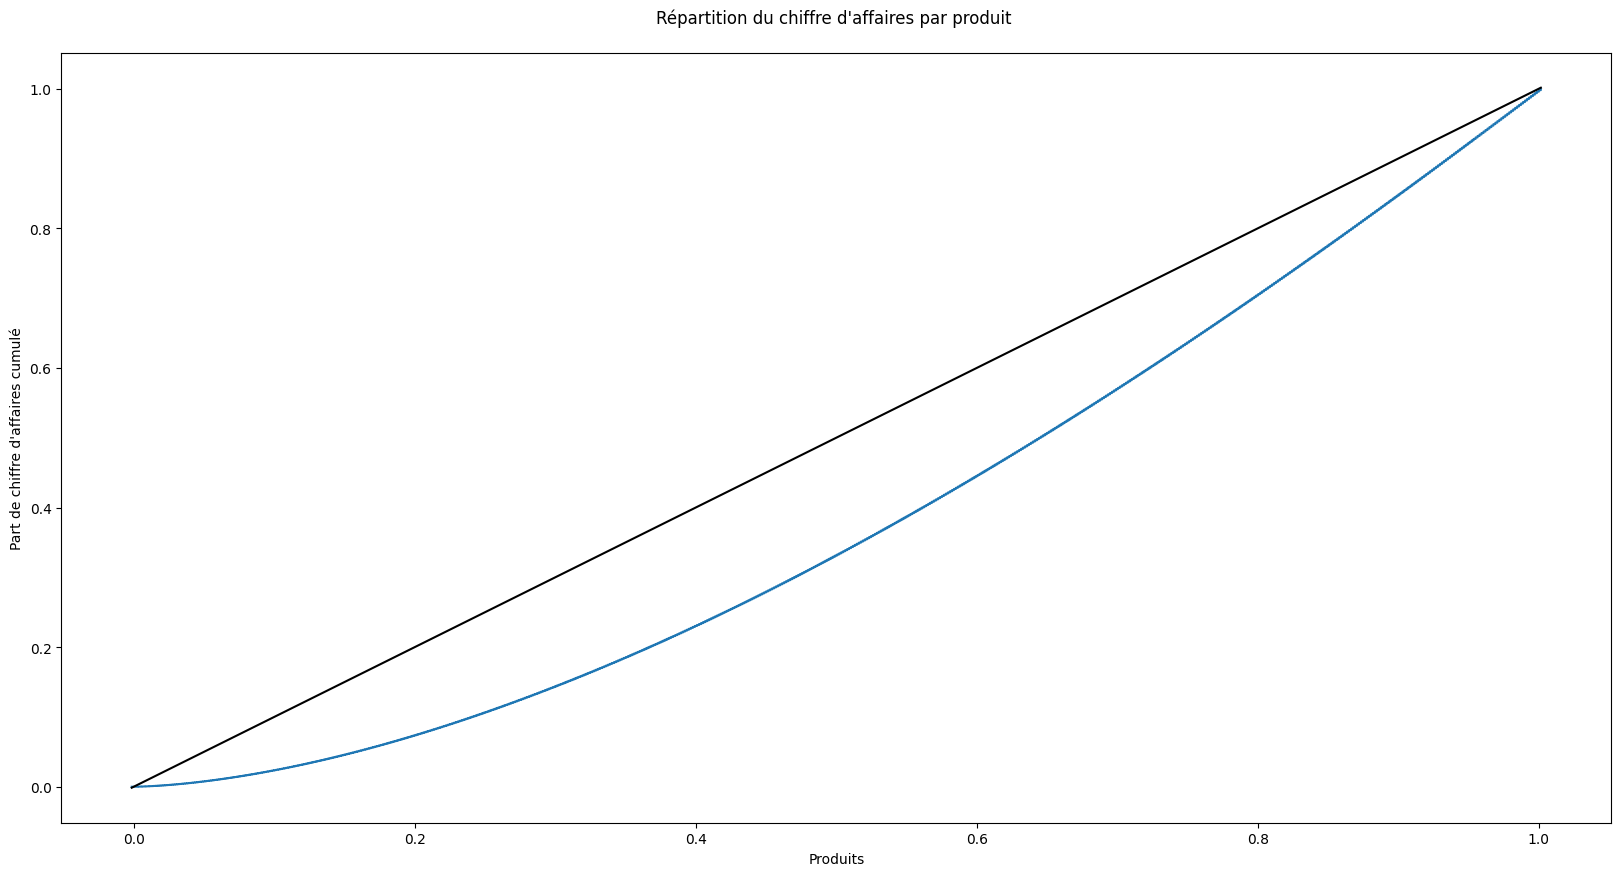

In [119]:
#Créer la courbe de Lorenz :
cl_lor = df_merge_web_ca['cumul_part_ca'].values
n = len(cl_lor)
lorenz2 = np.cumsum(np.sort(cl_lor)) / cl_lor.sum()
lorenz2 = np.append([0],lorenz2)
fig = plt.figure(figsize=(20,10))
xaxis = np.linspace(0-1/n,1+1/n,n+1)

plt.plot(xaxis,lorenz2,drawstyle='steps-post')
plt.plot(xaxis,xaxis,'black', label = 'y = x')
plt.title("Répartition du chiffre d'affaires par produit \n")
plt.ylabel("Part de chiffre d'affaires cumulé")
plt.xlabel("Produits")
plt.show()

In [120]:
#Calcul de l'indice de Gini
gini_index = 1 - 2 * np.trapezoid(lorenz2, xaxis)
print(f"Indice de Gini : {gini_index:.4f}")

Indice de Gini : 0.2247


In [121]:
#Ce résultat de l'indice de Gini indique que la répartition du chiffre d'affaires entre les produits est assez équitable.
#Il n'y a pas de concentration forte du chiffre d'affaires sur un petit groupe d'articles.

## 5. 2 - Analyse des ventes en quantité

In [122]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premier articles en quantité

#Graphique en barre des 20 premiers articles avec plotly express


In [123]:
#Trier les quantités vendues dans l'ordre décroissant
df_merge_web_qte = df_merge_web.sort_values(by='total_sales', ascending=False)

In [124]:
#Réinitialiser l'index du dataset par un reset_index
df_merge_web_qte = df_merge_web_qte.reset_index(drop=True)

In [125]:
#Afficher les 20 premiers articles en quantité
df_merge_web_qte.head(20)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article
0,4867,1,9.9,121,instock,4.86,16148,both,16148,36.0,taxable,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,"<div>\n\nUn rosé minéral, fruité et d’une gran...",publish,closed,closed,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.838147,356.4
1,4203,1,9.9,74,instock,5.01,15415,both,15415,27.0,taxable,2.0,2018-02-15 14:33:42,2018-02-15 13:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin de gourmandise à boire sur la fraîcheur po...,publish,closed,closed,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.838147,267.3
2,4275,1,14.9,62,instock,7.78,14864,both,14864,24.0,taxable,2.0,2018-02-27 13:33:54,2018-02-27 12:33:54,Vin,I Fabbri Chianti Classico Lamole 2017,Un nez typique de petits fruits rouges. Une bo...,publish,closed,closed,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.650497,357.6
3,4726,1,12.7,0,outofstock,6.82,14950,both,14950,22.0,taxable,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,Vin,François Baur Pinot Noir Schlittweg 2017,"Un éclat de fruits, de la souplesse, de la ron...",publish,closed,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.733063,279.4
4,4647,1,28.5,45,instock,14.14,16525,both,16525,22.0,taxable,2.0,2018-04-17 09:28:58,2018-04-17 07:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"Sur ce sol très calcaire, la Croix Boissée dél...",publish,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.140087,627.0
5,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0
6,6129,1,5.2,68,instock,2.74,14570,both,14570,20.0,taxable,2.0,2019-06-28 18:01:06,2019-06-28 16:01:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Nez Séduisant et puissant. Bouquet de fleurs j...,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-1.014539,104.0
7,4220,1,11.6,48,instock,5.75,15758,both,15758,18.0,taxable,2.0,2018-02-16 10:54:27,2018-02-16 09:54:27,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,"Un Touraine Amboise fin et élégant, un joli ch...",publish,closed,closed,frissant-chenin-pierres-2018,2020-08-27 11:45:02,2020-08-27 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.774346,208.8
8,5778,1,5.8,44,instock,3.09,15561,both,15561,17.0,taxable,2.0,2019-03-15 10:20:59,2019-03-15 09:20:59,Vin,Maurel Pays d'Oc Merlot 2018,<div>Robe rouge rubis avec des reflets violine...,publish,closed,closed,maurel-pays-d-oc-merot-2018,2020-08-14 10:55:02,2020-08-14 08:55:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.992021,98.6
9,5803,1,17.1,47,instock,9.19,13572,both,13572,17.0,taxable,2.0,2019-03-19 11:33:39,2019-03-19 10:33:39,Vin,Château Tour Haut-Caussan Médoc 2015,Vous trouverez dans cet

In [126]:
#Créer un graphique en barre avec les 20 premiers articles avec plotly express
fig = px.bar(
    df_merge_web_ca.head(20),
    x='total_sales',
    y='post_title',
    orientation='h',
    title='Top 20 des articles par nombre de ventes',
    labels={'total_sales': 'Nombre de ventes', 'post_title': 'Article'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})  # ordre croissant
fig.show()

In [127]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web


In [128]:
#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge_web_qte['part_qte'] = df_merge_web_qte['total_sales'] / df_merge_web_qte['total_sales'].sum()
df_merge_web_qte.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,part_qte
0,4867,1,9.9,121,instock,4.86,16148,both,16148,36.0,taxable,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,"<div>\n\nUn rosé minéral, fruité et d’une gran...",publish,closed,closed,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.838147,356.4,0.006267
1,4203,1,9.9,74,instock,5.01,15415,both,15415,27.0,taxable,2.0,2018-02-15 14:33:42,2018-02-15 13:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin de gourmandise à boire sur la fraîcheur po...,publish,closed,closed,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.838147,267.3,0.004701
2,4275,1,14.9,62,instock,7.78,14864,both,14864,24.0,taxable,2.0,2018-02-27 13:33:54,2018-02-27 12:33:54,Vin,I Fabbri Chianti Classico Lamole 2017,Un nez typique de petits fruits rouges. Une bo...,publish,closed,closed,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.650497,357.6,0.004178
3,4726,1,12.7,0,outofstock,6.82,14950,both,14950,22.0,taxable,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,Vin,François Baur Pinot Noir Schlittweg 2017,"Un éclat de fruits, de la souplesse, de la ron...",publish,closed,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.733063,279.4,0.003830
4,4647,1,28.5,45,instock,14.14,16525,both,16525,22.0,taxable,2.0,2018-04-17 09:28:58,2018-04-17 07:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"Sur ce sol très calcaire, la Croix Boissée dél...",publish,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.140087,627.0,0.003830


In [129]:
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_web_qte['cumul_part_qte'] = df_merge_web_qte['part_qte'].cumsum()
df_merge_web_qte.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,part_qte,cumul_part_qte
0,4867,1,9.9,121,instock,4.86,16148,both,16148,36.0,taxable,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,"<div>\n\nUn rosé minéral, fruité et d’une gran...",publish,closed,closed,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.838147,356.4,0.006267,0.006267
1,4203,1,9.9,74,instock,5.01,15415,both,15415,27.0,taxable,2.0,2018-02-15 14:33:42,2018-02-15 13:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin de gourmandise à boire sur la fraîcheur po...,publish,closed,closed,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.838147,267.3,0.004701,0.010968
2,4275,1,14.9,62,instock,7.78,14864,both,14864,24.0,taxable,2.0,2018-02-27 13:33:54,2018-02-27 12:33:54,Vin,I Fabbri Chianti Classico Lamole 2017,Un nez typique de petits fruits rouges. Une bo...,publish,closed,closed,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.650497,357.6,0.004178,0.015146
3,4726,1,12.7,0,outofstock,6.82,14950,both,14950,22.0,taxable,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,Vin,François Baur Pinot Noir Schlittweg 2017,"Un éclat de fruits, de la souplesse, de la ron...",publish,closed,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.733063,279.4,0.003830,0.018976
4,4647,1,28.5,45,instock,14.14,16525,both,16525,22.0,taxable,2.0,2018-04-17 09:28:58,2018-04-17 07:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"Sur ce sol très calcaire, la Croix Boissée dél...",publish,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.140087,627.0,0.003830,0.022806


In [130]:
#Calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qte = (df_merge_web_qte['cumul_part_qte'] <= 0.8).sum()
nb_articles_80_qte

np.int64(432)

In [131]:
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80_qte = nb_articles_80_qte / len(df_merge_web_qte)
proportion_articles_80_qte

np.float64(0.5236363636363637)

## 5. 3 - Analyse des stocks

In [132]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy

#Création de la colonne Rotation de stock

#Remplacement des "inf" par 0

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

In [133]:
#Coût d'achat
df_merge_web['cout_achat'] = df_merge_web['total_sales']*df_merge_web['purchase_price']
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91
635,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,696.36
209,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,642.74
630,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,434.20
708,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,415.94


In [134]:
#Calcul du stock_moyen
df_merge_web['stock_moyen'] = (df_merge_web['stock_quantity'] + df_merge_web['total_sales'])/2
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5
635,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,696.36,52.0
209,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,642.74,70.5
630,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,434.20,27.0
708,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,415.94,11.5


In [135]:
#Ratio rotation des stocks
df_merge_web['rotation_stock'] = df_merge_web['cout_achat'] / df_merge_web['stock_moyen']
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5,275.620000
635,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,696.36,52.0,13.391538
209,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,642.74,70.5,9.116879
630,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,434.20,27.0,16.081481
708,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,415.94,11.5,36.168696


In [136]:
#Durée moyenne de stockage
df_merge_web['duree_moyenne_stockage'] = 360 / df_merge_web['rotation_stock']
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5,275.620000,1.306146
635,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,696.36,52.0,13.391538,26.882647
209,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,642.74,70.5,9.116879,39.487195
630,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,434.20,27.0,16.081481,22.385997
708,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,415.94,11.5,36.168696,9.953359


In [137]:
#Trouver les "inf"
df_merge_web[df_merge_web['rotation_stock'] == np.inf]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage


In [138]:
#Il n'y a pas de valeurs "inf" dans la colonne "rotation_stock"

In [139]:
#Par contre, il faut vérifier s'il y a des valeurs non numériques dans la colonne "rotation_stock".
#En effet, les colonnes "total_sales" et "stock_quantity" peuvent être à zéro.

In [140]:
#Vérifier s'il existe des valeurs non numériques dans la colonne "rotation_stock"
presence_non_numeriques = df_merge_web['rotation_stock'].apply(lambda x: not str(x).replace('.', '', 1).isdigit()).any()
presence_non_numeriques

np.True_

In [141]:
#Calculer le nombre de lignes de la colonne "rotation_stock" ayant des valeurs non numériques
nb_non_numeriques = (~pd.to_numeric(df_merge_web['rotation_stock'], errors="coerce").notna()).sum()
nb_non_numeriques

np.int64(134)

In [142]:
#Afficher les premières lignes pour vérification
non_numeriques = df_merge_web[~pd.to_numeric(df_merge_web['rotation_stock'], errors="coerce").notna()]
non_numeriques.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage
221,4396,1,62.0,0,outofstock,28.42,9636,both,9636,0.0,taxable,2.0,2018-03-22 10:44:57,2018-03-22 09:44:57,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,The Hive est un assemblage de malts du Speysid...,publish,closed,closed,whisky-wemyss-the-hive-12-ans,2020-08-19 17:45:03,2020-08-19 15:45:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.117171,0.0,0.0,0.0,NaN,NaN
531,5544,1,61.6,0,outofstock,31.51,14828,both,14828,0.0,taxable,2.0,2018-11-26 09:52:56,2018-11-26 08:52:56,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,Ce Chassagne Montrachet se révèle être un vin ...,publish,closed,closed,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-03-27 09:30:10,2020-03-27 08:30:10,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.102159,0.0,0.0,0.0,NaN,NaN
28,4065,1,19.5,0,outofstock,9.67,15022,both,15022,0.0,taxable,2.0,2018-02-12 13:14:22,2018-02-12 12:14:22,Vin,Oratoire Saint Martin Cairanne Rouge Les Douye...,"Le rustique noble incarné. Beau grain, beaucou...",publish,closed,closed,oratoire-saint-martin-cairanne-douyes-2016,2020-08-27 18:45:02,2020-08-27 16:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.477858,0.0,0.0,0.0,NaN,NaN
723,6301,1,40.5,0,outofstock,20.51,15745,both,15745,0.0,taxable,2.0,2019-10-05 10:57:58,2019-10-05 08:57:58,Vin,Borie La Vitarèle Saint-Chinian Midi Rouge 2015,"Midi Rouge, le petit dernier de la Vitarèle co...",publish,closed,closed,borie-la-vitarele-saint-chinian-midi-rouge-2015,2020-06-18 10:45:06,2020-06-18 08:45:06,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.310274,0.0,0.0,0.0,NaN,NaN
578,5707,1,10.8,0,outofstock,5.69,13557,both,13557,0.0,taxable,2.0,2019-01-31 14:13:47,2019-01-31 13:13:47,Vin,Domaine des Terres d'Ocre Saint-Pourçain Rouge...,Le nez est marqué par des notes de fruits roug...,publish,closed,closed,domaine-des-terres-docre-saint-pourcain-rouge-...,2020-06-23 18:35:01,2020-06-23 16:35:01,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,-0.804370,0.0,0.0,0.0,NaN,NaN


In [143]:
#Les lignes ayant des valeurs de "rotation_stock" non numériques seront suppriméees.
#Elles ne seront pas prises en compte pour la suite des analyses car il n'est pas possible de les exploiter de la même manière que le reste des lignes.

In [144]:
#Supprimer les lignes ayant des valeurs non numériques dans "rotation_stock"
df_merge_web = df_merge_web[pd.to_numeric(df_merge_web['rotation_stock'], errors="coerce").notna()]
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage
208,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5,275.620000,1.306146
635,5892,1,191.3,98,instock,116.06,14983,both,14983,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,5.969813,1147.8,696.36,52.0,13.391538,26.882647
209,4353,1,79.5,127,instock,45.91,12587,both,12587,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.773948,1113.0,642.74,70.5,9.116879,39.487195
630,5826,1,41.2,34,instock,21.71,15325,both,15325,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.336545,824.0,434.20,27.0,16.081481,22.385997
708,6212,1,115.0,16,instock,59.42,13996,both,13996,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,3.106266,805.0,415.94,11.5,36.168696,9.953359


In [145]:
#Vérifier que la suppression a bien fonctionné
presence_non_numeriques_2 = df_merge_web['rotation_stock'].apply(lambda x: not str(x).replace('.', '', 1).isdigit()).any()
presence_non_numeriques_2

np.False_

In [146]:
#Trier le nombre de mois de stock par ordre décroissant
df_merge_web = df_merge_web.sort_values(by='rotation_stock', ascending=False)

In [147]:
#S'assurer de fixer le dataframe pour la suite
df_merge_web = df_merge_web.reset_index(drop=True)

In [148]:
#Créer un graphique en barre avec les flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(
    df_merge_web.head(20),
    x='rotation_stock',
    y='post_title',
    orientation='h',
    title='Flop 20 des articles ayant le plus de mois de stock',
    labels={'rotation_stock': 'Nombre de jours de rotation', 'post_title': 'Article'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [149]:
#Créer un graphique en barre avec les Top 20 des produits qui ont le moins de mois de stock
fig = px.bar(
    df_merge_web.tail(20),
    x='rotation_stock',
    y='post_title',
    orientation='h',
    title='Top 20 des articles ayant le moins de mois de stock',
    labels={'rotation_stock': 'Nombre de jours de rotation', 'post_title': 'Article'}
)
fig.update_layout(yaxis={'categoryorder': 'total descending'})
fig.show()

In [150]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros

#Calculer la somme de la colonne "Valorisation_stock_euros"

In [151]:
#Création de la colonne "valorisation_stocks_euros"
df_merge_web['valorisation_stocks_euros'] = df_merge_web['stock_quantity'] * df_merge_web['purchase_price']
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage,valorisation_stocks_euros
0,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5,275.62,1.306146,0.0
1,5565,1,92.0,0,outofstock,46.11,19822,both,19822,1.0,taxable,2.0,2018-11-26 10:59:10,2018-11-26 09:59:10,Vin,Tempier Bandol Cabassaou 2017,"<div id=""wrapper"">\n<div id=""container-wrapper...",publish,closed,closed,tempier-bandol-cabassaou-2017,2020-01-04 13:57:04,2020-01-04 12:57:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.243074,92.0,46.11,0.5,92.22,3.903709,0.0
2,6299,1,78.0,0,outofstock,41.51,15710,both,15710,4.0,taxable,2.0,2019-10-05 10:46:15,2019-10-05 08:46:15,Vin,Lucien Boillot Gevrey Chambertin 1er Cru Les C...,Un vin d'une grande pureté et d'une amplitude ...,publish,closed,closed,lucien-boillot-gevrey-chambertin-1er-cru-les-c...,2020-07-03 09:30:12,2020-07-03 07:30:12,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.717653,312.0,166.04,2.0,83.02,4.336305,0.0
3,6632,1,52.7,0,outofstock,26.41,15794,both,15794,2.0,taxable,2.0,2020-01-23 12:06:12,2020-01-23 11:06:12,Vin,Weingut Besson-Strasser Zürich Pinot Noir Chlo...,"<span title="""">Des fruits rouges des bois en b...",publish,closed,closed,weingut-besson-strasser-zurich-pinot-noir-chlo...,2020-08-21 18:25:02,2020-08-21 16:25:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.768141,105.4,52.82,1.0,52.82,6.815600,0.0
4,4636,1,50.0,0,outofstock,25.58,2361,both,2361,4.0,taxable,2.0,2018-04-14 12:20:54,2018-04-14 10:20:54,Vin,Marcel Windholtz Eau de Vie de Framboise d'Alsace,Les eaux de vie naissent d'une subtile alchimi...,publish,closed,closed,marcel-windholtz-eau-de-vie-de-framboise-dalsace,2020-08-15 09:00:13,2020-08-15 07:00:13,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.666810,200.0,102.32,2.0,51.16,7.036747,0.0


In [152]:
#Calculer la somme de la colonne "Valorisation_stock_euros"
df_merge_web['valorisation_stocks_euros'].sum()

np.float64(277022.17)

In [153]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity

In [154]:
#Calcul de la somme de la colonne "sotck_quantity"
df_merge_web['stock_quantity'].sum()

np.int64(16717)

## 5. 4 - Analyse du taux de marge

In [155]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT

#Création de la colonne Taux de marge

#Afficher le prix minimum de la colonne "taux_marge"

#Afficher le prix maximum de la colonne "taux_marge"


In [156]:
#Création de la colonne prix HT
#Ici, le prix d'achat correspond au prix HT donc sera utilisé la colonne "purchase_price"

In [157]:
#Création de la colonne taux de marge
df_merge_web['taux_marge'] = (df_merge_web['price'] - df_merge_web['purchase_price']) / df_merge_web['purchase_price']
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage,valorisation_stocks_euros,taux_marge
0,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5,275.62,1.306146,0.0,0.632683
1,5565,1,92.0,0,outofstock,46.11,19822,both,19822,1.0,taxable,2.0,2018-11-26 10:59:10,2018-11-26 09:59:10,Vin,Tempier Bandol Cabassaou 2017,"<div id=""wrapper"">\n<div id=""container-wrapper...",publish,closed,closed,tempier-bandol-cabassaou-2017,2020-01-04 13:57:04,2020-01-04 12:57:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.243074,92.0,46.11,0.5,92.22,3.903709,0.0,0.995229
2,6299,1,78.0,0,outofstock,41.51,15710,both,15710,4.0,taxable,2.0,2019-10-05 10:46:15,2019-10-05 08:46:15,Vin,Lucien Boillot Gevrey Chambertin 1er Cru Les C...,Un vin d'une grande pureté et d'une amplitude ...,publish,closed,closed,lucien-boillot-gevrey-chambertin-1er-cru-les-c...,2020-07-03 09:30:12,2020-07-03 07:30:12,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.717653,312.0,166.04,2.0,83.02,4.336305,0.0,0.879065
3,6632,1,52.7,0,outofstock,26.41,15794,both,15794,2.0,taxable,2.0,2020-01-23 12:06:12,2020-01-23 11:06:12,Vin,Weingut Besson-Strasser Zürich Pinot Noir Chlo...,"<span title="""">Des fruits rouges des bois en b...",publish,closed,closed,weingut-besson-strasser-zurich-pinot-noir-chlo...,2020-08-21 18:25:02,2020-08-21 16:25:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.768141,105.4,52.82,1.0,52.82,6.815600,0.0,0.995456
4,4636,1,50.0,0,outofstock,25.58,2361,both,2361,4.0,taxable,2.0,2018-04-14 12:20:54,2018-04-14 10:20:54,Vin,Marcel Windholtz Eau de Vie de Framboise d'Alsace,Les eaux de vie naissent d'une subtile alchimi...,publish,closed,closed,marcel-windholtz-eau-de-vie-de-framboise-dalsace,2020-08-15 09:00:13,2020-08-15 07:00:13,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.666810,200.0,102.32,2.0,51.16,7.036747,0.0,0.954652


In [158]:
#Afficher le prix minimum de la colonne "taux_marge"
df_merge_web['taux_marge'].min()

-0.8367320598864222

In [159]:
#Afficher le prix maximum de la colonne "taux_marge"
df_merge_web['taux_marge'].max()

1.296949650863653

In [160]:
#création d'un dataframe avec les taux positifs

#Afficher le prix minimum de la colonne "taux_marge"

#Afficher le prix maximum de la colonne "taux_marge"


In [161]:
#Création d'un dataframe avec les taux positifs
df_merge_web_taux_positif = df_merge_web[df_merge_web['taux_marge'] > 0]
df_merge_web_taux_positif.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,non_numerique,z_score,ca_par_article,cout_achat,stock_moyen,rotation_stock,duree_moyenne_stockage,valorisation_stocks_euros,taux_marge
0,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,7.234577,2475.0,1515.91,5.5,275.62,1.306146,0.0,0.632683
1,5565,1,92.0,0,outofstock,46.11,19822,both,19822,1.0,taxable,2.0,2018-11-26 10:59:10,2018-11-26 09:59:10,Vin,Tempier Bandol Cabassaou 2017,"<div id=""wrapper"">\n<div id=""container-wrapper...",publish,closed,closed,tempier-bandol-cabassaou-2017,2020-01-04 13:57:04,2020-01-04 12:57:04,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,2.243074,92.0,46.11,0.5,92.22,3.903709,0.0,0.995229
2,6299,1,78.0,0,outofstock,41.51,15710,both,15710,4.0,taxable,2.0,2019-10-05 10:46:15,2019-10-05 08:46:15,Vin,Lucien Boillot Gevrey Chambertin 1er Cru Les C...,Un vin d'une grande pureté et d'une amplitude ...,publish,closed,closed,lucien-boillot-gevrey-chambertin-1er-cru-les-c...,2020-07-03 09:30:12,2020-07-03 07:30:12,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,1.717653,312.0,166.04,2.0,83.02,4.336305,0.0,0.879065
3,6632,1,52.7,0,outofstock,26.41,15794,both,15794,2.0,taxable,2.0,2020-01-23 12:06:12,2020-01-23 11:06:12,Vin,Weingut Besson-Strasser Zürich Pinot Noir Chlo...,"<span title="""">Des fruits rouges des bois en b...",publish,closed,closed,weingut-besson-strasser-zurich-pinot-noir-chlo...,2020-08-21 18:25:02,2020-08-21 16:25:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.768141,105.4,52.82,1.0,52.82,6.815600,0.0,0.995456
4,4636,1,50.0,0,outofstock,25.58,2361,both,2361,4.0,taxable,2.0,2018-04-14 12:20:54,2018-04-14 10:20:54,Vin,Marcel Windholtz Eau de Vie de Framboise d'Alsace,Les eaux de vie naissent d'une subtile alchimi...,publish,closed,closed,marcel-windholtz-eau-de-vie-de-framboise-dalsace,2020-08-15 09:00:13,2020-08-15 07:00:13,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,False,0.666810,200.0,102.32,2.0,51.16,7.036747,0.0,0.954652


In [162]:
#Afficher le prix minimum de la colonne "taux_marge"
df_merge_web_taux_positif['taux_marge'].min()

0.5539739027283511

In [163]:
#Afficher le prix maximum de la colonne "taux_marge"
df_merge_web_taux_positif['taux_marge'].max()

1.296949650863653

In [164]:
#création d'un dataframe avec le taux de marge moyen par type de produit

#Affichage dans un graphique du taux de marge par type de produit


In [165]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_merge_web_taux_moyen = df_merge_web.groupby('product_type')['taux_marge'].mean()
df_merge_web_taux_moyen

,taux_marge
product_type,
Champagne,0.625306
Cognac,1.187794
Gin,1.097902
Huile d'olive,0.600682
Vin,0.938343
Whisky,1.180817


In [166]:
#Créer un graphique du taux de marge par type de produit
fig = px.bar(
    df_merge_web_taux_moyen.head(20),
    x=df_merge_web_taux_moyen.head(20).values,
    y=df_merge_web_taux_moyen.head(20).index,
    orientation='h',
    title='Taux de marge moyen par type de produit'
)
fig.update_layout(
    xaxis_title='Taux de marge moyen',
    yaxis_title='Type de produit',
    yaxis=dict(categoryorder='total ascending')
)
fig.show()

## 5. 5 - Analyse des corrélations entre les variables stock, sales et price

In [167]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn

#Création d'un heatmap de correlation avec les variables stock, sales et price
#on peut également créer un mask pour n'afficher qu'une demi heatmap

In [168]:
#Calculer la matrice de corrélation
correlation_matrix = df_merge_web[['stock_quantity', 'total_sales', 'price']].corr()

In [169]:
#Créer le heatmap
fig = px.imshow(
    correlation_matrix,
    text_auto=True,
    color_continuous_scale='RdBu',
    title='Heatmap de corrélation',
    labels={'color': 'Corrélation'}
)
fig.show()

In [170]:
#Que peut-on conclure des correlations ?
#Il y des corrélations moyennes entre stock_quantity et total_sales.
#Par contre, les corrélations sont négativement faibles entre price et stock_quantity.
#Et il n'y a pas quasiment pas de corrélation entre total_sales et price.

## 5. 6 - Mettre à disposition la nouvelle table sur un fichier Excel

In [171]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.

In [172]:
#Créer un fichier Excel de df_merge_web
df_merge_web.to_excel('df_merge_web.xlsx', index=False)